# [Submission Source Code] GKLaunch: Measuring Significant Goalkeepers Contributions in the Attacking Phases

## This notebook contains the implementation of the GKLaunch metric.
### Considerations:
- As mentioned in the assignment, this should fully work within a clean environment.
- The data is directly loaded from the 'opendata' GitHub repository.

### Prerequisites
The development was done on **Python 3.12 with pip**. Please make sure those are installed.

1. Create the virtual environment.

```bash
virtualenv aor_submission
```

2. Activate it.

```bash
!aor_submission\Scripts\activate
```

3. Install the packages from the requirements file using pip.

```bash
!pip install -r requirements.txt
```

#### Python libraries imports, constant values declarations & other commands

In [21]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from src.utils import *
from src.data_processing import *
from src.chains_data_processing import *
from src.feature_creation import *

In [22]:
match_ids = [
    1886347,
    1899585,
    1925299,
    1953632,
    1996435,    
    2006229,
    2011166,
    2013725,
    2015213,
    2017461,
]

pitch_width = 105
pitch_height = 68

skillcorner_opendata_media_url = "https://media.githubusercontent.com/media/SkillCorner/opendata/master/data/matches/"
skillcorner_opendata_raw_url = "https://raw.githubusercontent.com/SkillCorner/opendata/master/data/matches/"

skillcorner = SkillCornerData()
fc = FeatureCreation()
cdp = GKChains()
utils = Utils()

#### Importing the data & Data Processing
- Dropping NaN from the tracking data
- Getting minutes played information from the players metadata
- Filtering player possessions dynamic events

In [23]:
td_df = skillcorner.load_tracking_data(skillcorner_opendata_media_url, match_ids=match_ids)

pm_list = skillcorner.prepare_metadata_files(skillcorner_opendata_raw_url, match_ids=match_ids)
pm_df = skillcorner.load_metadata(pm_list)
pm_df = skillcorner.process_players_metadata_dataframe(pm_df)

de_list = skillcorner.prepare_dynamic_events_files(skillcorner_opendata_raw_url, match_ids=match_ids)
de_df = skillcorner.load_dynamic_events_data(de_list)
de_df = skillcorner.filter_player_possessions(de_df)

c:\Users\bogda\Desktop\projects\python\analytics_cup_research\src\data_processing.py:167: DtypeWarning: Columns (276) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.concat(
c:\Users\bogda\Desktop\projects\python\analytics_cup_research\src\data_processing.py:167: DtypeWarning: Columns (75,77,184,264) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.concat(


#### Data Processing - tagging GK-led chains and GK-led chains with possession ending in the attacking final third

In [24]:
gk_chains = []
i = 0

for (match_id, chain_id), chain_group in de_df.groupby(['match_id', 'possession_chain_id']):
    chain_result = cdp.analyze_gk_chain(chain_group, i)
    i += 1
    if chain_result:
        gk_chains.append(chain_result)

gk_chains_df = pd.DataFrame(gk_chains)

#### Data Processing - this presents an analysis on the GK-led possession chains: chains outcomes, average chain length etc.

In [25]:
cdp.get_gk_chains_info(gk_chains_df=gk_chains_df)


=== GK-Started Possession Chain Analysis ===
Total GK-started chains: 119

Chains reaching attacking third: 24 (20.2%)
Chains ending in attacking third: 21 (17.6%)

=== Chain Outcomes ===
end_type
pass               93
possession_loss    18
shot                6
foul_suffered       1
clearance           1
Name: count, dtype: int64

=== For chains reaching attacking third ===
Total: 24

How they ended:
end_type
pass               12
shot                6
possession_loss     5
foul_suffered       1
Name: count, dtype: int64

Led to shot: 6
Led to goal: 1

Average chain length: 8.4 possessions

=== Starting Phase Distribution ===
start_phase
build_up      70
create        24
direct        11
chaotic        9
disruption     3
transition     2
Name: count, dtype: int64

=== Average Chain Length by Outcome ===
                             mean  median  min  max
reached_attacking_third                            
False                    4.821053     4.0    1   17
True                     8.

#### Merging the GK chains with the corresponding tracking data

In [26]:
synced_df = gk_chains_df.merge(
    td_df,
    left_on=["match_id", "frame_end"],
    right_on=["match_id", "frame"],
    suffixes=("_event", "_tracking"),
)

In [27]:
synced_df.head()

,match_id,frame_start,frame_end,possession_chain_id,team_id,team_name,chain_length,x_start,x_end,y_start,...,possession_index,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group
0,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-42.28,-0.41,51009,True,430,2025-12-28 00:00:42,1.0,51009.0,away team
1,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-44.81,-13.35,176224,True,430,2025-12-28 00:00:42,1.0,51009.0,away team
2,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-46.19,5.38,51649,True,430,2025-12-28 00:00:42,1.0,51009.0,away team
3,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-31.93,-22.36,50983,True,430,2025-12-28 00:00:42,1.0,51009.0,away team
4,1886347,387,430,5,1805,Newcastle,3,-47.3,-42.28,-2.23,...,4,-43.20,20.02,735578,True,430,2025-12-28 00:00:42,1.0,51009.0,away team


#### Applying changes to the DataFrame coordinates

In [28]:
synced_df = utils.apply_coords_to_df(synced_df, pitch_width, pitch_height)

#### Create a list of possible features to be then integrated to the model

Created features include:

    - coordinates of the goalkeeper after save attempt (end coords) + their squared values
    - distance from the goalkeeper end coords to the middle of the pitch
    - distance from the last successful chain event to the goal and its squared value
    - angle to the goal from the last successful chain event
    - match period (first/second half)
    - maximum forward distance on x-axis
    - total distance reached and duration
    - progression speed (ratio between total distance reached and total duration)
    - directness of the chain
    - the label

In [29]:
model_features_df = fc.create_features_dataframe(synced_df.possession_index.unique(), synced_df)

#### Checking the most statistically relevant features from the recently created list

In [30]:
test_model1 = smf.glm(formula="gk_led_to_final_third ~ d2 + max_x_reached ",
                      data = model_features_df,
                      family = sm.families.Binomial()).fit()

summary_text = test_model1.summary()
print(summary_text)

                   Generalized Linear Model Regression Results                   
Dep. Variable:     gk_led_to_final_third   No. Observations:                  119
Model:                               GLM   Df Residuals:                      116
Model Family:                   Binomial   Df Model:                            2
Link Function:                     Logit   Scale:                          1.0000
Method:                             IRLS   Log-Likelihood:                -59.791
Date:                   Sun, 28 Dec 2025   Deviance:                       119.58
Time:                           02:21:24   Pearson chi2:                     119.
No. Iterations:                        4   Pseudo R-squ. (CS):          0.0005556
Covariance Type:               nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       

#### Train-test splitting, training and predicting probabilities using the Random Forest model

In [31]:
X_train, X_test, y_train, y_test = train_test_split(model_features_df[test_model1.params.keys()[1:]], model_features_df['gk_led_to_final_third'], test_size=0.33, random_state=42)

# Train the RandomForest classifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Predict probabilities for the test set
y_probs = clf.predict_proba(model_features_df[test_model1.params.keys()[1:]])[::, 1]

model_features_df["GKLaunch"] = y_probs

#### Generating a plot with the ROC score and the features relevance summary

ROC-AUC Score: 0.82


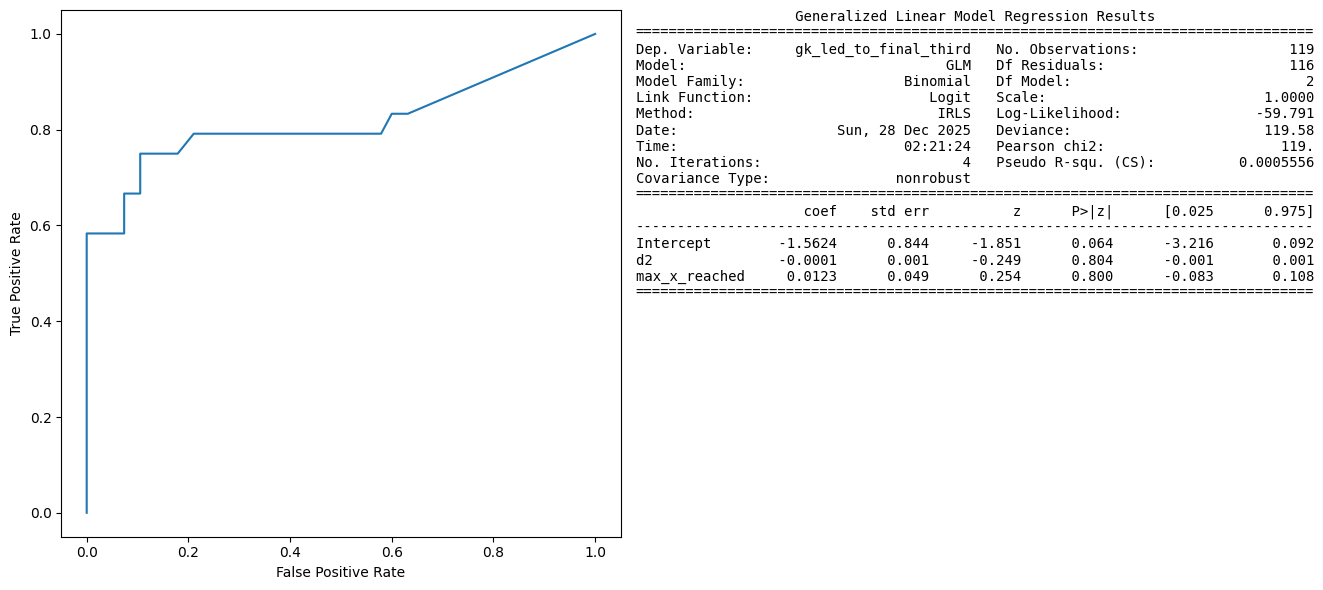

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

roc_auc = roc_auc_score(model_features_df['gk_led_to_final_third'], y_probs)
print(f'ROC-AUC Score: {roc_auc:.2f}')

fpr, tpr, thresholds = roc_curve(model_features_df['gk_led_to_final_third'], y_probs)
axes[0].plot(fpr, tpr)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate') 

axes[1].axis("off")
axes[1].text(
    0, 1, summary_text,
    fontsize=10,
    va="top",
    family="monospace"
)

plt.tight_layout()
plt.show()

#### Integrating the result DataFrame with the players metadata to get full information about the goalkeepers

In [33]:
result_df = model_features_df.groupby(["gkId"])["GKLaunch"].sum().sort_values(ascending=False).reset_index()
result_df = result_df.merge(
    pm_df,
    how="left",
    left_on=["gkId"],
    right_on=["id"]
)

#### Normalizing the metrics

In [34]:
fc.add_normalized_metrics_to_dataframe(result_df)

#### And the results are in...

In [35]:
result_df.sort_values('GKLaunchPer90', ascending=False)[['short_name', 'team_name', 'total_minutes_played', 'total_minutes_played_tip', 'total_minutes_played_otip', 'GKLaunchPer90', 'GKLaunchPer30TIP', 'GKLaunchPer30OTIP']]

,short_name,team_name,total_minutes_played,total_minutes_played_tip,total_minutes_played_otip,GKLaunchPer90,GKLaunchPer30TIP,GKLaunchPer30OTIP
4,M. Freke,Brisbane Roar FC,102.13,37.19,22.84,2.03,1.86,3.02
0,A. Paulsen,Auckland FC,396.50,103.63,98.72,1.45,1.86,1.95
1,M. Sutton,Western United,194.48,46.26,58.59,1.31,1.83,1.44
5,E. Cox,Adelaide United Football Club,96.00,24.64,28.97,1.30,1.69,1.44
2,H. Devenish-Meares,Sydney Football Club,190.65,56.93,49.56,1.16,1.29,1.48
3,P. Beach,Melbourne City FC,197.47,68.33,40.09,1.08,1.04,1.78
6,C. Cook,Perth Glory Football Club,102.13,22.84,37.19,1.03,1.54,0.94
8,R. Scott,Newcastle United Jets FC,98.40,22.20,31.13,0.91,1.34,0.95
7,J. Oluwayemi,Wellington Phoenix FC,199.67,46.61,49.12,0.51,0.73,0.70
9,F. Kurto,Macarthur FC,98.75,21.92,31.90,0.34,0.51,0.35
